# Reaction Cross Section — From Matter Density

This notebook shows how to compute reaction cross sections using the Glauber model and matter densities $\rho_m(r)$.
It loads matter densities, converts them from a radial form $\rho_m(r)$ to an impact-parameter form $\rho_m(b)$, constructs a profile function, and evaluates reaction cross sections using the Optical Limit Approximation (OLA) and the Modified Optical Limit (MOL).  (see textbook as  Structure and Reactions of Light Exotic Nuclei by Y. Suzuki, K. Yabana, R. G. Lovas, and K. Varga)

Notes: units are used consistently where appropriate: radius r and impact parameter b in fm; matter densities $\rho_m(r)$ in $\mathrm{fm}^{-3} $ and for $\rho_m(b)$ in $\mathrm{fm}^{-2}$; cross sections are reported in millibarns (mb).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
# Load ERICCa (assumes the ERICCa kernel/environment is available)
import ERICCA as ERICCa

## 1) Matter densities for $^{12}\mathrm{C}$

### Load external density 


Load example $^{12}\mathrm{C}$ matter densities (mass density) that were precomputed using Fayans EDF. The files contain radial meshes r [fm] and matter densities $\rho_m(r)$ [$\mathrm{fm}^{-3} $]. We use one sample (first row) for the demonstration.

Loaded matter density arrays:
C12_matter_density.shape = (500, 31)
r_mesh.shape = (500, 31)


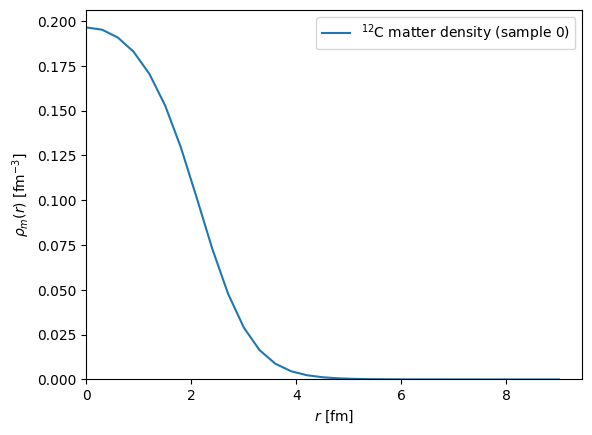

In [2]:
# Load radial matter density files (paths are relative to the tutorials folder)
C12_matter_density = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack=True)  # shape: (n_samples, n_r)
r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack=True)  # shape: (n_samples, n_r)

print('Loaded matter density arrays:')
print('C12_matter_density.shape =', C12_matter_density.shape)
print('r_mesh.shape =', r_mesh.shape)

plt.plot(r_mesh[0], C12_matter_density[0], color='C0', label=r'$^{12}$C matter density (sample 0)')
plt.xlabel(r'$r$ [fm]')
plt.ylabel(r'$\rho_m(r)$ [fm$^{-3}$]')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.show()

### Use a fitted 2-Point Fermi Density 

If tabulated densities are unavailable, **ERICCa** can generate a fitted **two-point Fermi density** using the `Density` class and the `rho_m_2pt_fermi` helper function.
This function fits the parameters **$C_m$ (radius)**, **$a_m$ (diffuseness)**, and **$\rho_0$** to  reproduce the mass number, the rms radius and the saturation density $\rho_m(0)=0.176$ $\mathrm{fm}^{-3} $

The analytical form of the 2-point Fermi density is:
$$
\rho_m(r) = \rho_0 \left[1 + \exp\left(\frac{r - C_m}{a_m}\right)\right]^{-1}
$$

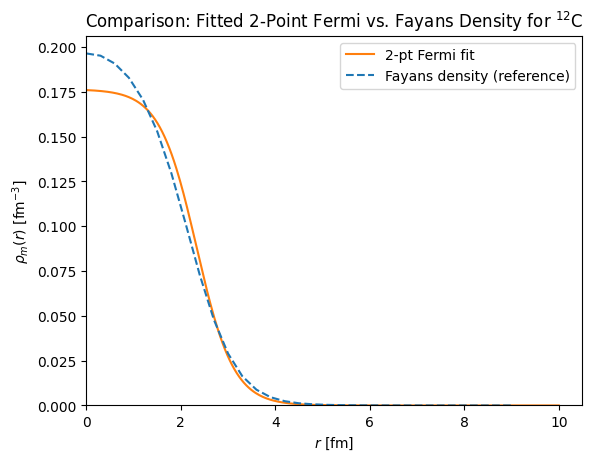

Fitted 2-point Fermi parameters for $^{12}$C:
C_m   = 2.334 fm  (radius)
a_m   = 0.391 fm  (diffuseness)
rho_0 = 0.176 fm⁻³


In [3]:
# --- Fit a 2-point Fermi density for ¹²C ---
# Initialize a Density instance and fit parameters to a target RMS radius
my_12C_rho = ERICCa.Density()  # Density helper instance

# Fit the two-point Fermi parameters (C_m, a_m, rho_0) to match the RMS radius, the mass number and the saturation density fixed at 0.176
A_12C = 12                     # Mass number of Carbon-12
rms_12C = 2.32                 # Target matter RMS radius [fm] (example value)
my_12C_rho.rho_m_2pt_fermi(A_12C, rms_12C)

# --- Plot the fitted density vs. Fayans density ---
# Generate a radial mesh for plotting
fit_r_mesh = np.linspace(0.001, 10.0, 400)

# Plot the fitted 2-point Fermi density and the reference Fayans density
plt.plot(fit_r_mesh, my_12C_rho.rho_m(fit_r_mesh), color='C1', label='2-pt Fermi fit')
plt.plot(r_mesh[0], C12_matter_density[0], color='C0', linestyle='--', label='Fayans density (reference)')

# Add labels, title, and legend
plt.xlabel(r'$r$ [fm]')
plt.ylabel(r'$\rho_m(r)$ [fm$^{-3}$]')
plt.title('Comparison: Fitted 2-Point Fermi vs. Fayans Density for $^{12}$C')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend()
plt.show()

# --- Print fitted parameters ---
print('Fitted 2-point Fermi parameters for $^{12}$C:')
print(f'C_m   = {my_12C_rho.C_m_p:.3f} fm  (radius)')
print(f'a_m   = {my_12C_rho.a_m_p:.3f} fm  (diffuseness)')
print(f'rho_0 = {my_12C_rho.rho_0_p:.3f} fm⁻³')


### Computing the RMS Radius of a Matter Density

The `Density` class in **ERICCa** provides a utility method `rms(r_mesh, rho_mesh, A)` to compute the **root-mean-square (RMS) radius** of a matter density distribution.
The method takes the following inputs:
- `r_mesh`: Radial mesh in **fm**.
- `rho_mesh`: Matter density values in **fm⁻³**.
- `A`: Mass number of the nucleus.

In [4]:
# --- Compute RMS radii for comparison ---
# Calculate the RMS radius of the Fayans density (sample 0) and the fitted 2-point Fermi density
rms_fayans = my_12C_rho.rms(r_mesh[0], C12_matter_density[0], 12)  # Fayans density RMS radius
rms_fitted = my_12C_rho.rms(fit_r_mesh, my_12C_rho.rho_m(fit_r_mesh), 12)  # Fitted 2-pt Fermi RMS radius

# Print the computed RMS radii for comparison
print('RMS Radii Comparison for $^{12}$C:')
print(f'  Fayans density (sample 0): {rms_fayans:.3f} fm')
print(f'  Fitted 2-pt Fermi:        {rms_fitted:.3f} fm')

RMS Radii Comparison for $^{12}$C:
  Fayans density (sample 0): 2.417 fm
  Fitted 2-pt Fermi:        2.320 fm


## 2) Profile Function $\Gamma(b)$


The **profile function** $\Gamma(b)$ describes the effective interaction strength as a function of the **impact parameter** ($b$).
In ERICCa, the `ProfileFunction` class implements $\Gamma(b)$ with the following analytical form:


$$\Gamma(b) = \frac{(1 - i \alpha)}{4 \pi \beta} \cdot \sigma_{NN} \cdot \exp\left(-\frac{b^2}{2 \beta}\right)$$

$\alpha$ us dimensionless, $\beta$ is in $\mathrm{fm}^{2} $ and $\sigma_{NN}$ is the nucleon-nucleon cross section in  $\mathrm{fm}^{2} $.

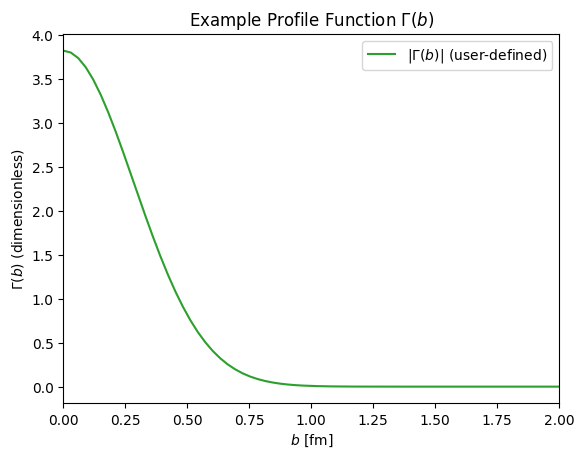

In [5]:
# --- Example: User-defined Profile Function ---
# Initialize a ProfileFunction instance (default: model_type='general', E=100 MeV)
profile_funct = ERICCa.ProfileFunction()

# Set example parameters 
profile_funct.alpha = 0.326     # unitless
profile_funct.beta = 0.081      # fm^2
profile_funct.sigma_n = 3.7     # fm^2

# --- Plot the profile function Γ(b) ---
# Generate an impact-parameter mesh (b in fm)
b_mesh = np.linspace(0.0, 6.0, 200)

# Plot Γ(b) vs. b
plt.plot(b_mesh, np.abs(profile_funct.Gamma(b_mesh)), color='C2', label=r'|$\Gamma(b)$| (user-defined)')

plt.xlabel(r'$b$ [fm]')  # Impact parameter
plt.ylabel(r'$\Gamma(b)$ (dimensionless)')  # Profile function
plt.title('Example Profile Function $\\Gamma(b)$')
plt.legend()
plt.xlim(0,2)
plt.show()

## 3) Cross Section Setup and Mesh Configuration

The `ERICCa.CrossSection` class handles cross-section calculations and requires proper **mesh configuration** for numerical integration.
Before performing calculations, you must:
1. **Define the mesh extents** (maximum values for \(r\), \(b\), and \(z\)).
2. **Set the resolution** (number of grid points for each dimension).
3. **Call `update_mesh()`** to apply the settings.

These meshes control the **internal integration** for:
- Eikonal phase calculations.
- Cross-section computations.
- Other numerical operations in ERICCa.

**Note:** Adjust the mesh settings based on your **precision requirements** and **performance constraints**.


In [6]:
# --- Initialize CrossSection and Configure Mesh ---
# Create a CrossSection instance
cross_section = ERICCa.CrossSection()

# --- Set mesh extents (maximum values for internal integration) ---
cross_section.rmax = 25    # Maximum radial coordinate [fm]
cross_section.bmax = 20    # Maximum impact parameter [fm]
cross_section.zmax = 5     # Maximum z-coordinate for internal integrals [fm]

# --- Set mesh resolution (number of grid points) ---
cross_section.numpoints = 40          # General grid points
cross_section.numpoints_theta = 40   # Angular grid points
cross_section.r_numpoints = 30       # Radial grid points
cross_section.b_numpoints = 50       # Impact parameter grid points
cross_section.z_numpoints = 30       # z-coordinate grid points

# --- Apply the mesh settings ---
# Update internal meshes to reflect the new configuration
cross_section.update_mesh()

### Converting Radial Density to Impact-Parameter Density $\rho(b)$

To perform cross-section calculations, the **3D radial matter density** $\rho_m(r)$ must be converted to a **2D impact-parameter density** $\rho(b)$ by integration over the longitudinal coordinate $z$:

$$
\rho(b) = \int_{-\infty}^{\infty} \rho_m(r) \, dz \quad \text{where} \quad r = \sqrt{b^2 + z^2}
$$

ERICCa provides the `dens_b_interpolator` method for this conversion. The method:
1. **Integrates** the radial density over $z$ to obtain $\rho(b)$
2. **Interpolates** the result onto the **internal impact-parameter mesh** of the `CrossSection` object
3. Ensures consistency with other calculations in the framework

This conversion transforms the density from 3D space $\mathrm{fm}^{-3} $ to the 2D impact-parameter plane $\mathrm{fm}^{-2} $.

In [427]:
# --- Convert Radial Density to Impact-Parameter Density ---
# Convert the first sample of the Fayans density to ρ(b) using the cross_section mesh
C12_matter_density_b = cross_section.dens_b_interpolator(
    r_mesh[0],  # Radial mesh (fm)
    C12_matter_density[0]  # Radial density ρ_m(r) (fm⁻³)
)  # Returns ρ(b) (fm⁻²), aligned with cross_section.b_mesh

# Print the length of the converted density array for verification
print('Converted matter density to impact-parameter form: ρ(b) length =', len(C12_matter_density_new_mesh))

Converted matter density to impact-parameter form: ρ(b) length = 40


## 4) Reaction Cross Section for $^{12}\mathrm{C}$ + $^{12}\mathrm{C}$

To compute the **reaction cross section** $\sigma_R$ for a **$^{12}\mathrm{C}$ + $^{12}\mathrm{C}$** collision, we use ERICCa's `sigma_R_matter` method. We can compute the cross sections in the Optical Limit Approximation (OLA) and the Modified Optical Limit Approximation (MOL) (see textbook as  Structure and Reactions of Light Exotic Nuclei by Y. Suzuki, K. Yabana, R. G. Lovas, and K. Varga)

In [428]:
# --- Compute Reaction Cross Sections for $^{12}$C + $^{12}$C ---
# Use the matter-density-based method with both OLA and MOL models

# Compute sigma_R using the Modified Optical Limit (MOL) model
sigma_R_MOL = cross_section.sigma_R_matter(
    rho_t=C12_matter_density_b,  # Target density ρ_t(b) [fm⁻²]
    rho_p=C12_matter_density_b,  # Projectile density ρ_p(b) [fm⁻²]
    Gamma=profile_funct.Gamma,          # Profile function Γ(b)
    Model='MOL'                         # Modified Optical Limit
)

# Compute sigma_R using the Optical Limit Approximation (OLA) model
sigma_R_OLA = cross_section.sigma_R_matter(
    rho_t=C12_matter_density_b,
    rho_p=C12_matter_density_b,
    Gamma=profile_funct.Gamma,
    Model='OLA'  # Optical Limit Approximation
)

# Print results with consistent formatting
print('Reaction cross sections for $^{12}$C + $^{12}$C:')
print(f'  σ_R (MOL) = {sigma_R_MOL:.3f} mb')
print(f'  σ_R (OLA) = {sigma_R_OLA:.3f} mb')

Reaction cross sections for $^{12}$C + $^{12}$C:
  σ_R (MOL) = 846.387 mb
  σ_R (OLA) = 883.293 mb
